In [1]:
import json
import pandas as pd
import random
from tqdm import tqdm
from google.colab import drive
import matplotlib.pyplot as plt
drive.mount('/content/drive')
pd.options.display.max_rows = 50
pd.options.display.max_columns = 50

Mounted at /content/drive


In [2]:
csv_file_path = '/content/drive/MyDrive/final_yelp_PA_FL.parquet'
df = pd.read_parquet(csv_file_path)
df

,review_id,user_id,business_id,stars,useful,funny,cool,text,date,name,address,city,state,postal_code,latitude,longitude,stars_business,review_count,is_open,attributes,categories,hours,name_user,review_count_user,yelping_since,useful_user,funny_user,cool_user,elite,friends,fans,average_stars,compliment_hot,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos,checkin_count,compliment_count
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,Turning Point of North Wales,1460 Bethlehem Pike,North Wales,PA,19454,40.210196,-75.223639,3.0,169,1,"{'AcceptsInsurance': None, 'AgesAllowed': None...","Restaurants, Breakfast & Brunch, Food, Juice B...","{'Friday': '7:30-15:0', 'Monday': '7:30-15:0',...",Melanie,33,2016-01-13 17:20:44,32,3,8,,"DS9QBM_NWJz1E279Zrao-A, XdXgIs4i5JFvtJf0rJlWsA...",0,4.06,0,0,0,0,0,0,0,1,1,0,0,177.0,0.0
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18,Body Cycle Spinning Studio,"1923 Chestnut St, 2nd Fl",Philadelphia,PA,19119,39.952103,-75.172753,5.0,144,0,"{'AcceptsInsurance': None, 'AgesAllowed': None...","Active Life, Cycling Classes, Trainers, Gyms, ...","{'Friday': '6:0-19:30', 'Monday': '6:30-20:30'...",Erin,10,2011-03-07 19:45:15,6,1,2,,"7uYgWwryg8KH33i1SLJUTQ, 0mGJMNL8o2AY4BT1d4TTDQ...",0,4.30,0,0,0,0,0,0,0,0,0,0,0,497.0,0.0
2,J-4NdnDZ0pUQaUEEwDI9KQ,vrKkXsozqqecF3CW4cGaVQ,rjuWz_AD3WfXJc03AhIO_w,5.0,2,2,2,I thoroughly enjoyed the show. Chill way to s...,2012-12-04 16:46:20,The N Crowd,111 S Independence Mall E,Philadelphia,PA,19106,39.949756,-75.148062,4.5,90,1,"{'AcceptsInsurance': None, 'AgesAllowed': None...","Performing Arts, Arts & Entertainment, Nightli...","{'Friday': '19:15-21:15', 'Monday': '0:0-0:0',...",Mike,120,2010-08-16 19:59:54,48,17,31,,"ZaUT63HFjheiub1y7019Yg, Obkepp5aBTYVX-AL4zwBoQ...",5,4.44,4,3,0,0,0,10,15,4,4,4,0,148.0,0.0
3,DyrAIuKl60j_X8Yrrv-kpg,mNsVyC9tQVYtzLOCbh2Piw,MWmXGQ98KbRo3vsS5nZhMA,5.0,1,0,0,I recently had dinner here with my wife over t...,2014-10-27 02:47:28,Anthony's at Paxon Hollow,850 Paxon Hollow Rd,Broomall,PA,19008,39.958108,-75.371118,3.5,32,1,"{'AcceptsInsurance': None, 'AgesAllowed': None...","Event Planning & Services, Italian, Venues & E...","{'Friday': '12:0-21:0', 'Monday': None, 'Satur...",Michael,12,2014-07-20 22:56:07,43,6,2,,RKULSOrIvvYpDmtuYXEXzA,0,2.53,0,0,0,0,0,0,0,0,0,0,0,15.0,0.0
4,40thYphUgIfvJq17QCfTwA,QzCEzH3R7Z6erOGLr3t55Q,0pMj5xUAecW9o1P35B0AMw,5.0,1,0,1,Great staff always helps and always nice. Alwa...,2017-05-26 13:10:24,Wawa,2544 W Main Street,Norristown,PA,19403,40.141292,-75.389286,3.5,8,1,"{'AcceptsInsurance': None, 'AgesAllowed': None...","Food, Coffee & Tea, Gas Stations, Restaurants,...","{'Friday': '0:0-0:0', 'Monday': '0:0-0:0', 'Sa...",Kylhalil,14,2012-03-05 19:12:11,5,2,2,,"POmz_WtE-nowjX5H7s9NSA, PEYAcshPlYwY-YP-55Re4Q...",0,4.36,0,0,0,0,0,0,0,0,0,0,0,79.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
673685,rtt1Ymczj-1Lb26JMsY2lA,M1cMsRL4L7IUr9RILDywEQ,vt_esoDw6HG5ClM12OPkMg,4.0,4,3,4,"5 stars for the Bonte waffle, 3 stars for this...",2009-03-03 20:59:10,Bonté Wafflerie & Café,130 S 17th St,Philadelphia,PA,19102,39.950510,-75.169205,3.5,115,0,"{'AcceptsInsurance': None, 'AgesAllowed': None...","Coffee & Tea, Restaurants, Breakfast & Brunch,...","{'Friday': '6:30-18:0', 'Monday': '6:30-18:0',...",Matt,2227,2006-10-24 22:40:11,5681,1342,2430,"2008,2009,2010,2011,2012,2013,2014,2015,2016,2...","TLElemg3o3mlA4GGpupNiQ, REGjppkq2IkDLRQVmRj_Bg...",277,3.78,59,30,10,13,36,79,116,150,150,128,41,193.0,0.0
673686,5n_oSwXspiiSsZgNwjp48g,bJ5FtCtZX3ZZacz2_2PJjA,SOsjW1JARmtHUFtpFlp8rw,4.0,5,

In [ ]:
df.columns

Index(['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny',
       'cool', 'text', 'date', 'name', 'address', 'city', 'state',
       'postal_code', 'latitude', 'longitude', 'stars_business',
       'review_count', 'is_open', 'attributes', 'categories', 'hours',
       'name_user', 'review_count_user', 'yelping_since', 'useful_user',
       'funny_user', 'cool_user', 'elite', 'friends', 'fans', 'average_stars',
       'compliment_hot', 'compliment_more', 'compliment_profile',
       'compliment_cute', 'compliment_list', 'compliment_note',
       'compliment_plain', 'compliment_cool', 'compliment_funny',
       'compliment_writer', 'compliment_photos', 'checkin_count',
       'compliment_count'],
      dtype='object')

🗂️ Yelp Open Dataset — структура и описание JSON-файлов
1. yelp_academic_dataset_business.json

Описание: информация о бизнесах (ресторанах, кафе, салонах и т. д.).

Поле	Тип	Описание	Применение
business_id	str	Уникальный идентификатор бизнеса	🔹Primary key для связки с другими файлами
name	str	Название бизнеса	—
address	str	Адрес	Можно использовать для гео-анализа
city	str	Город	Фильтрация по региону
state	str	Штат (например, “PA”, “AZ”)	Отбор подмножества (ты фильтровал по state)
postal_code	str	Почтовый индекс	—
latitude, longitude	float	Координаты	Географические фичи (distance-based рекомендации)
stars	float	Средний рейтинг бизнеса (1–5)	🔹Item feature (качество / популярность)
review_count	int	Кол-во отзывов	🔹Признак популярности
is_open	int	1 = открыт, 0 = закрыт	Можно фильтровать неактивные бизнесы
attributes	dict	Словарь характеристик (“WiFi”, “Alcohol”, “Noise Level”, и т.п.)	🔹Категориальные признаки для item embedding
categories	str	Список категорий через запятую (“Restaurants, Italian”)	🔹Item feature (тип бизнеса)
hours	dict	Часы работы по дням недели	Можно извлечь “evening open” / “weekend open” как фичи

💡 Использование в ВКР:

признаки stars, review_count, categories, attributes идеально подходят для контентных фичей бизнеса;

state, city — фильтрация по региону;

можно получить one-hot-encoding по категориям.

2. yelp_academic_dataset_user.json

Описание: данные о пользователях, их активности и социальной информации.

Поле	Тип	Описание	Применение
user_id	str	Уникальный идентификатор пользователя	🔹Primary key
name	str	Имя	—
review_count	int	Кол-во написанных отзывов	🔹Признак активности
yelping_since	str (дата)	Когда пользователь зарегистрировался	Можно извлечь «стаж»
useful, funny, cool	int	Кол-во отметок на отзывы	🔹Показатель вовлечённости
fans	int	Кол-во подписчиков	🔹Признак популярности
average_stars	float	Средний рейтинг, который ставит пользователь	🔹Отражает строгость пользователя
friends	str (через запятую)	Список друзей	Можно посчитать friend_count
elite	str	Годы участия в программе “Yelp Elite”	—
compliment_*	int	Кол-во комплиментов за разные аспекты (“photos”, “cool”, “cute”, ...)	Можно агрегировать как показатель вовлечённости

💡 Использование:

review_count, average_stars, fans → фичи пользователя (user features).

Можно посчитать derived features:

activity_level = log(1 + review_count)

strictness = average_stars - 3.0

social_influence = fans + compliments_total.

3. yelp_academic_dataset_review.json

Описание: основная таблица взаимодействий — отзывы пользователей о бизнесах.
Это главный файл для формирования user–item матрицы.

Поле	Тип	Описание	Применение
review_id	str	Уникальный ID отзыва	—
user_id	str	ID пользователя	🔹связь с user.json
business_id	str	ID бизнеса	🔹связь с business.json
stars	int	Оценка (1–5)	🔹Основная target-переменная для CF
date	str	Дата отзыва	🔹для train/test сплита по времени
text	str	Текст отзыва	🔹для NLP фичей (sentiment, embeddings)
useful, funny, cool	int	Отметки других пользователей	🔹можно использовать как implicit feedback

💡 Использование:

Это главная таблица взаимодействий для CF, LightFM и ML-моделей.

Можно конвертировать в implicit матрицу (лайк / нет взаимодействия).

text можно обработать с помощью BERT → получить sentiment / embedding.

4. yelp_academic_dataset_checkin.json

Описание: данные о времени посещений (check-ins) пользователей в бизнесах.
Каждая запись соответствует одному бизнесу.

Поле	Тип	Описание	Применение
business_id	str	ID бизнеса	🔹связь с business.json
date	str	Строка с датами посещений (через запятую)	Можно получить число визитов и активные месяцы

💡 Использование:

рассчитать checkin_count = количество посещений,

извлечь сезонность (например, активность по месяцам),

контентный признак бизнеса (activity_popularity).

⚠️ Файл может быть тяжёлым и грузится долго, поэтому разумно ограничить по бизнесам из выбранного штата (что мы сделали).

5. yelp_academic_dataset_tip.json

Описание: короткие советы (tips), которые пользователи оставляют о бизнесах.
Это более короткие заметки, чем отзывы.

Поле	Тип	Описание	Применение
user_id	str	ID пользователя	🔹связь с user.json
business_id	str	ID бизнеса	🔹связь с business.json
text	str	Текст совета	🔹можно анализировать sentiment
date	str	Дата	—
compliment_count	int	Кол-во комплиментов под tip	🔹признак популярности бизнеса

💡 Использование:

можно посчитать tip_count или avg_compliments как показатель интереса,

можно объединить с review для создания text-features.

⚙️ Итоговые связи между файлами
user.json         → user_id
review.json       → user_id, business_id
business.json     → business_id
checkin.json      → business_id
tip.json          → business_id, user_id


После объединения (merge) через review.json ты получаешь полную таблицу final_df, в которой есть:

Категория	Примеры признаков	Источник
User features	review_count_x, average_stars, fans, useful, compliments	user.json
Item features	stars_y, review_count_y, checkin_count, categories	business.json, checkin.json
Interaction features	stars_x, text, date	review.json
Доп. signals	tip_compliments, sentiment (BERT)	tip.json, NLP

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 673690 entries, 0 to 673689
Data columns (total 45 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   review_id           673690 non-null  object 
 1   user_id             673690 non-null  object 
 2   business_id         673690 non-null  object 
 3   stars               673690 non-null  float64
 4   useful              673690 non-null  int64  
 5   funny               673690 non-null  int64  
 6   cool                673690 non-null  int64  
 7   text                673690 non-null  object 
 8   date                673690 non-null  object 
 9   name                673690 non-null  object 
 10  address             673690 non-null  object 
 11  city                673690 non-null  object 
 12  state               673690 non-null  object 
 13  postal_code         673690 non-null  object 
 14  latitude            673690 non-null  float64
 15  longitude           673690 non-nul

In [ ]:
df.describe()

,stars,useful,funny,cool,latitude,longitude,stars_business,review_count,is_open,review_count_user,useful_user,funny_user,cool_user,fans,average_stars,compliment_hot,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos,checkin_count,compliment_count
count,673690.000000,673690.000000,673690.000000,673690.000000,673690.000000,673690.000000,673690.000000,673690.000000,673690.000000,673690.000000,673690.000000,673690.000000,673690.000000,673690.000000,673690.000000,673690.000000,673690.000000,673690.000000,673690.000000,673690.000000,673690.000000,673690.000000,673690.000000,673690.000000,673690.000000,673690.000000,673690.000000,673690.000000
mean,3.802167,1.465502,0.434139,0.686528,35.142576,-78.183196,3.761244,319.804961,0.801101,186.813530,695.244313,280.404273,475.330900,20.274562,3.790458,24.544782,3.485078,2.686979,1.766192,1.287959,22.794267,56.446689,44.351038,44.351038,16.282545,23.031869,683.070893,0.599482
std,1.348503,3.431075,1.809738,2.622258,5.916332,3.615184,0.697760,550.599775,0.399172,450.535832,4258.358302,2514.680013,3619.327583,106.406445,0.613214,271.496627,56.081060,68.344583,50.434982,45.820002,209.974753,751.346557,478.466548,478.466548,152.998571,478.172054,2116.044220,1.495438
min,1.000000,0.000000,0.000000,0.000000,27.564457,-90.074708,1.000000,5.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,0.000000,0.000000,27.979688,-82.503151,3.500000,48.000000,1.000000,19.000000,13.000000,2.000000,2.000000,0.000000,3.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,53.000000,0.000000
50%,4.000000,1.000000,0.000000,0.000000,39.943079,-75.323454,4.000000,139.000000,1.000000,53.000000,51.000000,10.000000,14.000000,1.000000,3.860000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,220.000000,0.000000
75%,5.000000,2.000000,0.000000,1.000000,39.970201,-75.162142,4.000000,350.000000,1.000000,174.000000,243.000000,59.000000,97.000000,9.000000,4.180000,3.000000,1.000000,1.000000,0.000000,0.000000,7.000000,6.000000,6.000000,6.000000,4.000000,2.000000,664.000000,1.000000
max,5.000000,227.000000,284.000000,207.000000,40.449748,-74.766048,5.000000,5721.000000,1.000000,17473.000000,206296.000000,185823.000000,199878.000000,12497.000000,5.000000,25784.000000,13501.000000,14180.000000,13654.000000,12669.000000,59031.000000,101097.000000,49967.000000,49967.000000,15934.000000,82630.000000,52144.000000,22.000000


## EDA

In [ ]:
n_users = df["user_id"].nunique()
n_items = df["business_id"].nunique()
n_interactions = len(df)
print('n_users:', n_users)
print('n_items:', n_items)
print('n_interactions:', n_interactions)

n_users: 87154
n_items: 48208
n_interactions: 673690


In [ ]:
df["review_id"].nunique(), len(df)

(673690, 673690)

In [ ]:
dup_pairs = df.groupby(["user_id", "business_id"])["review_id"].count()
dup_pairs[dup_pairs > 1].sort_values(ascending=False).head()


,,review_id
user_id,business_id,
K_ZOHuFXE-_Sc5TadyoF5Q,2i08phNpJ938airDq5Af6w,8
d67zTET_2IuVoWcUU0aWaQ,dybSe2rNDk1hNMpes9y7Rw,8
dayvbWieWP_fFWrhDAOHyQ,NnlXgLZ93KPj1wYSiqjyIg,7
tvmJO7-aCNssNcGIAsPYFA,SZNnDfhSryMHfZCfifHl7w,7
OeMDHEXQcsq0ZGhk9Ta7qg,deQAlSgEXKuSPasPXkeotg,6


In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
missing

,0
hours,37454
attributes,13088
categories,45
user_id,0
review_id,0
funny,0
cool,0
text,0
date,0
name,0


In [ ]:
user_activity = df.groupby("user_id")["business_id"].nunique()
item_popularity = df.groupby("business_id")["user_id"].nunique()

user_activity.describe()


,business_id
count,87154.000000
mean,7.552161
std,13.696754
min,1.000000
25%,3.000000
50%,4.000000
75%,7.000000
max,954.000000


In [ ]:
item_popularity.describe()

,user_id
count,48208.000000
mean,13.653356
std,30.935343
min,1.000000
25%,3.000000
50%,5.000000
75%,12.000000
max,1457.000000


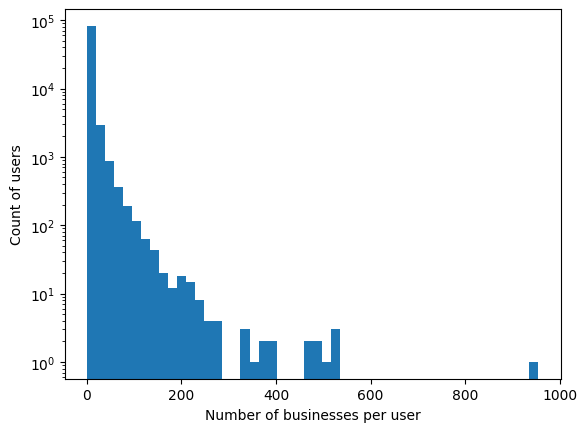

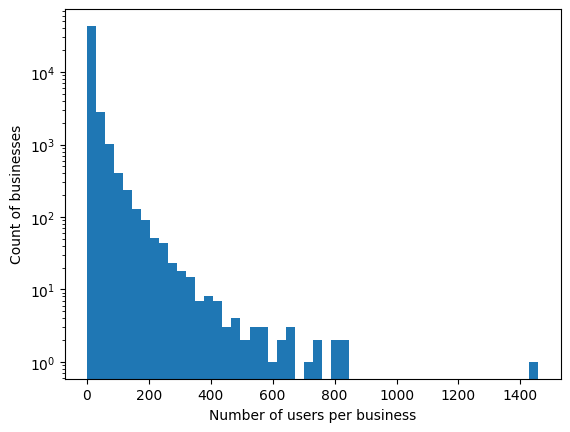

In [ ]:
import matplotlib.pyplot as plt

plt.hist(user_activity, bins=50)
plt.yscale("log")
plt.xlabel("Number of businesses per user")
plt.ylabel("Count of users")
plt.show()

plt.hist(item_popularity, bins=50)
plt.yscale("log")
plt.xlabel("Number of users per business")
plt.ylabel("Count of businesses")
plt.show()


In [ ]:
sparsity = 1 - n_interactions / (n_users * n_items)
sparsity

0.9998396556496533

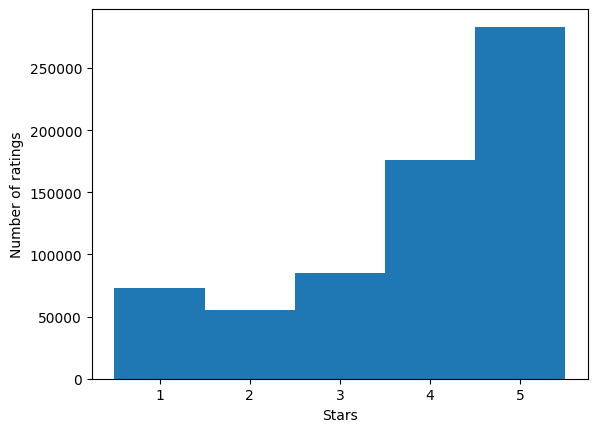

In [ ]:
df["stars"].value_counts(normalize=True).sort_index()

plt.hist(df["stars"], bins=[0.5,1.5,2.5,3.5,4.5,5.5])
plt.xlabel("Stars")
plt.ylabel("Number of ratings")
plt.show()


In [ ]:
df["text_len"] = df["text"].str.len()
df["text_words"] = df["text"].str.split().str.len()

df["text_len"].describe()


,text_len
count,673690.000000
mean,608.964476
std,539.977609
min,1.000000
25%,253.000000
50%,447.000000
75%,783.000000
max,5000.000000


In [ ]:
df["text_words"].describe()

,text_words
count,673690.000000
mean,112.156412
std,99.770738
min,1.000000
25%,46.000000
50%,82.000000
75%,145.000000
max,1031.000000


In [ ]:
df["categories"][1]

'Active Life, Cycling Classes, Trainers, Gyms, Fitness & Instruction'

In [ ]:
cat_series = df["categories"].dropna().str.split(", ")
from collections import Counter
cnt = Counter(cat for cats in cat_series for cat in cats)

In [ ]:
df['attributes'][1]

{'AcceptsInsurance': None,
 'AgesAllowed': None,
 'Alcohol': None,
 'Ambience': None,
 'BYOB': None,
 'BYOBCorkage': None,
 'BestNights': None,
 'BikeParking': 'True',
 'BusinessAcceptsBitcoin': None,
 'BusinessAcceptsCreditCards': 'True',
 'BusinessParking': "{'garage': False, 'street': True, 'validated': False, 'lot': False, 'valet': False}",
 'ByAppointmentOnly': 'False',
 'Caters': None,
 'CoatCheck': None,
 'Corkage': None,
 'DietaryRestrictions': None,
 'DogsAllowed': None,
 'DriveThru': None,
 'GoodForDancing': None,
 'GoodForKids': 'False',
 'GoodForMeal': None,
 'HairSpecializesIn': None,
 'HappyHour': None,
 'HasTV': None,
 'Music': None,
 'NoiseLevel': None,
 'Open24Hours': None,
 'OutdoorSeating': None,
 'RestaurantsAttire': None,
 'RestaurantsCounterService': None,
 'RestaurantsDelivery': None,
 'RestaurantsGoodForGroups': None,
 'RestaurantsPriceRange2': None,
 'RestaurantsReservations': None,
 'RestaurantsTableService': None,
 'RestaurantsTakeOut': None,
 'Smoking': None

In [ ]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [ ]:
df["date"].isna().sum()

np.int64(0)

In [ ]:
df["date"].describe()

,date
count,673690
mean,2016-07-22 15:15:22.001746432
min,2005-03-18 01:49:32
25%,2014-06-07 12:54:28.500000
50%,2016-11-19 17:24:51.500000
75%,2019-01-23 20:03:24.249999872
max,2022-01-19 19:29:46


In [ ]:
df["date"].min(), df["date"].max()

(Timestamp('2005-03-18 01:49:32'), Timestamp('2022-01-19 19:29:46'))

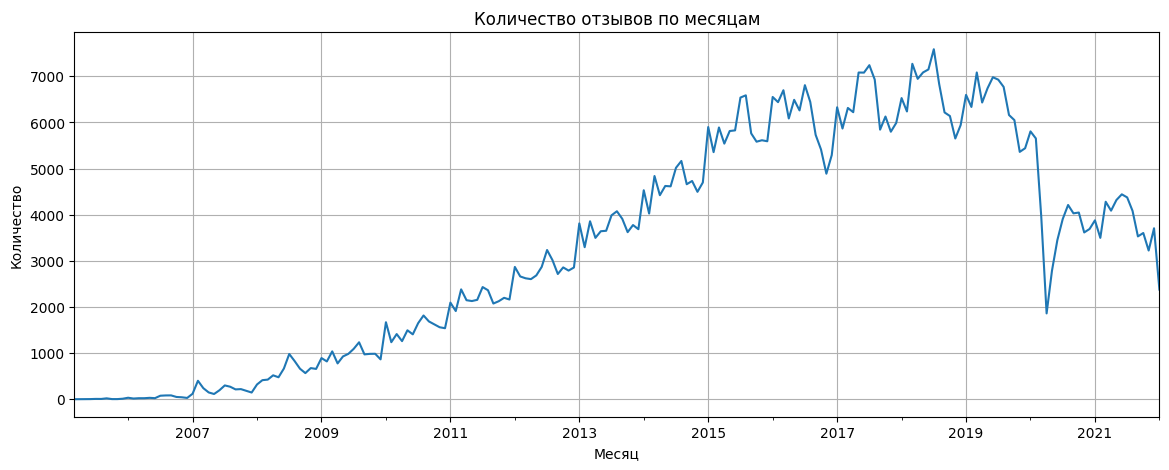

In [ ]:
df["year_month"] = df["date"].dt.to_period("M")
counts = df.groupby("year_month")["review_id"].count()

plt.figure(figsize=(14,5))
counts.plot()
plt.title("Количество отзывов по месяцам")
plt.ylabel("Количество")
plt.xlabel("Месяц")
plt.grid(True)
plt.show()


<Axes: xlabel='year'>

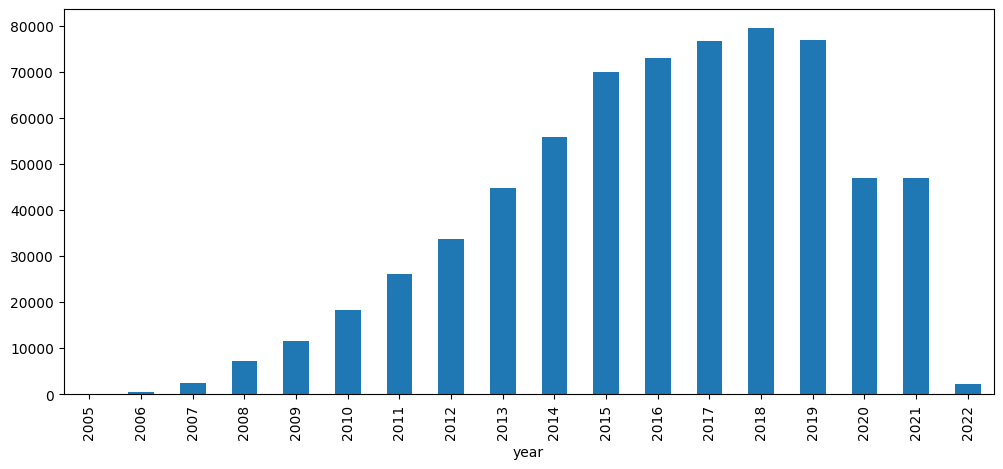

In [ ]:
df["year"] = df["date"].dt.year
df.groupby("year")["review_id"].count().plot(kind="bar", figsize=(12,5))

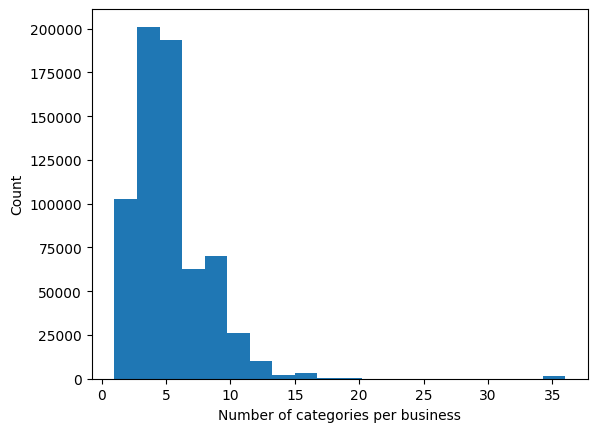

In [ ]:
import matplotlib.pyplot as plt

vals = [len(c) for c in cat_series]
plt.hist(vals, bins=20)
plt.xlabel("Number of categories per business")
plt.ylabel("Count")
plt.show()


In [ ]:
df_sorted = df.sort_values(["user_id", "date"])
test_idx = df_sorted.groupby("user_id").tail(1).index

test_cf = df.loc[test_idx]
train_cf = df.drop(test_idx)

print(len(train_cf), len(test_cf))


In [3]:
import pandas as pd
import numpy as np
import ast
from collections import Counter

# ---------- Categories: top-N ----------
def top_categories(df, col="categories", topn=50):
    s = df[col].dropna().astype(str)
    cats = s.str.split(",").explode().str.strip()
    cats = cats[cats != ""]
    return cats.value_counts().head(topn)

# ---------- Attributes: top-N ----------
def _safe_attr_dict(x):
    if isinstance(x, dict):
        return x
    if pd.isna(x) or x is None:
        return {}
    s = str(x)
    s = s.replace("u'", "'").replace('u"', '"')
    try:
        return ast.literal_eval(s)
    except Exception:
        return {}

def top_attributes(df, col="attributes", topn=50, mode="keys"):
    """
    mode:
      - "keys": самые частые ключи атрибутов (например, WiFi, Alcohol, BikeParking)
      - "key_true": самые частые булевы True (например, RestaurantsTakeOut=True)
      - "key_value": самые частые пары key=value (например, WiFi=no, Alcohol=full_bar)
    """
    cnt = Counter()

    for x in df[col].values:
        d = _safe_attr_dict(x)
        if not d:
            continue

        for k, v in d.items():
            if v is None:
                continue

            # вложенные dict часто лежат строкой -> попробуем распарсить
            if isinstance(v, str) and v.strip().startswith("{") and v.strip().endswith("}"):
                v2 = _safe_attr_dict(v)
                if isinstance(v2, dict):
                    # вложенные атрибуты: Ambience, BusinessParking, GoodForMeal и т.п.
                    if mode == "keys":
                        cnt[k] += 1
                    elif mode == "key_true":
                        for kk, vv in v2.items():
                            if vv is True or str(vv).strip().lower() == "true":
                                cnt[f"{k}.{kk}=True"] += 1
                    elif mode == "key_value":
                        for kk, vv in v2.items():
                            if vv is None:
                                continue
                            vv = str(vv).strip().strip("'").strip('"')
                            cnt[f"{k}.{kk}={vv}"] += 1
                    continue

            if mode == "keys":
                cnt[k] += 1
            else:
                vv = v
                if isinstance(vv, str):
                    vv = vv.strip().strip("'").strip('"')
                if mode == "key_true":
                    if vv is True or str(vv).strip().lower() == "true":
                        cnt[f"{k}=True"] += 1
                elif mode == "key_value":
                    cnt[f"{k}={vv}"] += 1

    return pd.Series(dict(cnt)).sort_values(ascending=False).head(topn)

# ====== usage ======
# лучше использовать items_meta (одна строка на business), иначе популярные бизнесы повторятся из-за отзывов
df_items = items_meta if "items_meta" in globals() else df

print("\nTop categories:")
print(top_categories(df_items, col="categories", topn=30))

print("\nTop attribute KEYS:")
print(top_attributes(df_items, col="attributes", topn=30, mode="keys"))

print("\nTop attribute TRUE flags:")
print(top_attributes(df_items, col="attributes", topn=30, mode="key_true"))

print("\nTop attribute key=value:")
print(top_attributes(df_items, col="attributes", topn=30, mode="key_value"))



Top categories:
categories
Restaurants                  488088
Food                         191957
Nightlife                    153925
Bars                         147211
American (New)               102346
American (Traditional)        99679
Breakfast & Brunch            83818
Sandwiches                    70634
Seafood                       56231
Italian                       53706
Pizza                         53435
Coffee & Tea                  48047
Shopping                      46445
Event Planning & Services     45992
Burgers                       39133
Mexican                       38055
Desserts                      33508
Salad                         31817
Beauty & Spas                 31644
Specialty Food                31601
Cafes                         29338
Arts & Entertainment          29210
Cocktail Bars                 28336
Chinese                       27795
Sushi Bars                    25523
Japanese                      25093
Wine & Spirits                25024



KeyboardInterrupt



In [ ]:
TOPN = 20

# топ популярных business_id по числу взаимодействий (в df_cf)
top_items = (df.groupby("business_id")["user_id"]
             .size()
             .sort_values(ascending=False)
             .head(TOPN)
             .reset_index(name="n_interactions"))

# подтягиваем метаданные бизнеса
top_items_meta = (top_items
                  .merge(df[["business_id","name","city","state","stars_business","review_count","is_open",
                                   "categories","attributes"]],
                         on="business_id", how="left")
                  .sort_values("n_interactions", ascending=False))

top_items_meta


In [ ]:
import ast
import pandas as pd

def parse_categories(s):
    if pd.isna(s) or s is None:
        return []
    return [x.strip() for x in str(s).split(",") if x.strip()]

def safe_attr_dict(x):
    if isinstance(x, dict):
        return x
    if pd.isna(x) or x is None:
        return {}
    s = str(x).replace("u'", "'").replace('u"', '"')
    try:
        return ast.literal_eval(s)
    except Exception:
        return {}

def pretty_attrs(attr, top_only=True):
    """
    top_only=True: выводим только "информативные" (не None) и True/значения.
    """
    d = safe_attr_dict(attr)
    out = {}
    for k, v in (d or {}).items():
        if v is None:
            continue

        # распарсим вложенный dict, если он строкой
        if isinstance(v, str) and v.strip().startswith("{") and v.strip().endswith("}"):
            v2 = safe_attr_dict(v)
            if isinstance(v2, dict):
                # оставим только True/непустые
                v2_clean = {kk: vv for kk, vv in v2.items()
                            if vv is not None and (vv is True or str(vv).strip().lower() != "false")}
                if v2_clean:
                    out[k] = v2_clean
                continue

        # скаляры
        vs = v
        if isinstance(vs, str):
            vs = vs.strip().strip("'").strip('"')
        if top_only and str(vs).strip().lower() == "false":
            continue
        out[k] = vs
    return out

for _, r in top_items_meta.iterrows():
    print("="*90)
    print(f"{r.get('name','')} | {r.get('city','')}, {r.get('state','')}  | "
          f"n={int(r['n_interactions'])} | stars_business={r.get('stars_business',None)} | "
          f"review_count={r.get('review_count',None)} | is_open={r.get('is_open',None)}")
    print("- Categories:")
    print(parse_categories(r.get("categories", None))[:50])  # обрежем, если слишком много
    print("- Attributes (clean):")
    print(pretty_attrs(r.get("attributes", None), top_only=True))


In [5]:
df_items = items_meta if "items_meta" in globals() else df.drop_duplicates("business_id")
print("unique businesses:", df_items["business_id"].nunique())


unique businesses: 48208


In [6]:
import pandas as pd

cats = (df_items["categories"]
        .fillna("")
        .astype(str)
        .str.split(",")
        .explode()
        .str.strip())

# частоты категорий по бизнесам: считаем "встречаемость категории у бизнеса" (а не число строк)
tmp = pd.DataFrame({
    "business_id": df_items["business_id"].repeat(df_items["categories"].fillna("").astype(str).str.split(",").str.len())
})

tmp["cat"] = cats.values
tmp = tmp[tmp["cat"] != ""].drop_duplicates(["business_id", "cat"])

top_cats = (tmp["cat"].value_counts().head(30))
share_restaurants = (tmp.assign(is_rest=tmp["cat"].eq("Restaurants"))
                       .groupby("business_id")["is_rest"].any().mean())

print("Top categories among businesses:")
print(top_cats)
print("\nShare of businesses tagged 'Restaurants':", round(float(share_restaurants), 3))


Top categories among businesses:
cat
Restaurants                  19612
Food                         10066
Shopping                      6864
Beauty & Spas                 4735
Nightlife                     4412
Bars                          4056
Home Services                 3842
Health & Medical              3531
Sandwiches                    3280
Local Services                3108
American (Traditional)        3088
Automotive                    3080
Event Planning & Services     2959
Pizza                         2942
Coffee & Tea                  2538
American (New)                2430
Active Life                   2400
Breakfast & Brunch            2396
Italian                       2066
Fast Food                     1802
Burgers                       1762
Nail Salons                   1702
Hair Salons                   1700
Auto Repair                   1646
Home & Garden                 1579
Fashion                       1567
Hotels & Travel               1540
Arts & Entertainme

In [7]:
SECTORS = [
    "Restaurants", "Food", "Shopping", "Beauty & Spas", "Health & Medical",
    "Home Services", "Automotive", "Nightlife", "Active Life", "Arts & Entertainment",
    "Event Planning & Services", "Hotels & Travel", "Professional Services", "Education"
]

biz_cats = (tmp.groupby("business_id")["cat"].apply(set))

sector_share = {}
for s in SECTORS:
    sector_share[s] = np.mean([s in sc for sc in biz_cats])

sector_share = pd.Series(sector_share).sort_values(ascending=False)
print(sector_share)


Restaurants                  0.407006
Food                         0.208899
Shopping                     0.142448
Beauty & Spas                0.098265
Nightlife                    0.091562
Home Services                0.079733
Health & Medical             0.073279
Automotive                   0.063919
Event Planning & Services    0.061408
Active Life                  0.049807
Hotels & Travel              0.031959
Arts & Entertainment         0.031897
Professional Services        0.017764
Education                    0.011061
dtype: float64


In [8]:
import numpy as np
import pandas as pd
import ast
from collections import Counter

# =========================
# 0) Config
# =========================
SEED = 42
np.random.seed(SEED)

MIN_USER_INTERACTIONS = 5   # чтобы анализ совпадал с твоим пайплайном
TOPN = 30                   # сколько топов печатаем

# =========================
# 1) Clean + user filter (как в пайплайне)
# =========================
df0 = df.copy()
df0["date"] = pd.to_datetime(df0["date"], errors="coerce")
df0 = (df0
       .dropna(subset=["user_id", "business_id", "date"])
       .sort_values(["user_id", "date"])
)

user_cnt = df0.groupby("user_id")["business_id"].size()
eligible_users = user_cnt[user_cnt >= MIN_USER_INTERACTIONS].index
df_cf = df0[df0["user_id"].isin(eligible_users)].copy()

print("Users:", df_cf["user_id"].nunique())
print("Interactions:", len(df_cf))
print("Businesses:", df_cf["business_id"].nunique())

# =========================
# 2) Target = last business per user
# =========================
targets = (df_cf.groupby("user_id").tail(1)
           .loc[:, ["user_id", "business_id", "date", "stars"]]
           .rename(columns={"stars": "target_user_stars"}))

print("\nTargets (one per user):", len(targets))

# =========================
# 3) Item meta (one row per business)
#    IMPORTANT: берем из df_cf (чтобы соответствовало срезу)
# =========================
need_item_cols = [c for c in [
    "business_id", "name", "city", "state",
    "categories", "attributes",
    "stars_business", "review_count", "is_open"
] if c in df_cf.columns]

items_meta = (df_cf[need_item_cols]
              .sort_values(["business_id"])
              .groupby("business_id", as_index=False)
              .first())

# counts of interactions per business (для interaction-weighted распределений)
biz_inter_cnt = df_cf.groupby("business_id").size().rename("n_interactions").reset_index()

# merge target meta
targets_meta = targets.merge(items_meta, on="business_id", how="left").merge(biz_inter_cnt, on="business_id", how="left")
targets_meta["n_interactions"] = targets_meta["n_interactions"].fillna(0).astype(int)

# =========================
# 4) Helpers: categories parsing + stats
# =========================
def explode_categories(df_x, id_col):
    """explode categories into rows: (id_col, cat)"""
    s = df_x["categories"].fillna("").astype(str).str.split(",")
    out = df_x[[id_col]].copy()
    out["cat"] = s
    out = out.explode("cat")
    out["cat"] = out["cat"].astype(str).str.strip()
    out = out[out["cat"] != ""]
    return out

def category_table_targets_vs_baselines(targets_meta, items_meta, biz_inter_cnt, topn=30):
    # Target distribution: how many users have target with category
    t = explode_categories(targets_meta, "user_id").drop_duplicates(["user_id", "cat"])
    tgt_users = t["cat"].value_counts()
    tgt_share = tgt_users / targets_meta["user_id"].nunique()

    # Business baseline: how many businesses have category
    b = explode_categories(items_meta, "business_id").drop_duplicates(["business_id", "cat"])
    biz_cnt = b["cat"].value_counts()
    biz_share = biz_cnt / items_meta["business_id"].nunique()

    # Interaction-weighted baseline: sum interactions over businesses that have category
    b2 = b.merge(biz_inter_cnt, on="business_id", how="left").fillna({"n_interactions": 0})
    inter_sum = b2.groupby("cat")["n_interactions"].sum().sort_values(ascending=False)
    inter_share = inter_sum / max(inter_sum.sum(), 1)

    # Combine
    all_cats = set(tgt_users.index) | set(biz_cnt.index) | set(inter_sum.index)
    out = pd.DataFrame(index=sorted(all_cats))
    out["target_users"] = tgt_users
    out["target_share"] = tgt_share
    out["businesses"] = biz_cnt
    out["business_share"] = biz_share
    out["interactions_sum"] = inter_sum
    out["interactions_share"] = inter_share

    out = out.fillna(0)
    out = out.sort_values("target_users", ascending=False).head(topn)
    return out

cat_report = category_table_targets_vs_baselines(targets_meta, items_meta, biz_inter_cnt, topn=TOPN)

print("\n=== Target category distribution (last item per user) vs baselines ===")
print(cat_report)

print("\nShare of targets that include 'Restaurants':",
      float((targets_meta["categories"].fillna("").astype(str).str.contains(r"\bRestaurants\b")).mean()))

# =========================
# 5) Sector-style summary (ручной список крупных классов)
# =========================
SECTORS = [
    "Restaurants", "Food", "Shopping", "Nightlife", "Active Life", "Arts & Entertainment",
    "Beauty & Spas", "Health & Medical", "Home Services", "Automotive",
    "Hotels & Travel", "Event Planning & Services", "Education", "Professional Services"
]

# For targets: share of users whose target has that sector
t_cats = explode_categories(targets_meta, "user_id").drop_duplicates(["user_id", "cat"])
t_user2cats = t_cats.groupby("user_id")["cat"].apply(set)

sector_share_targets = {s: np.mean([s in cs for cs in t_user2cats]) for s in SECTORS}
sector_share_targets = pd.Series(sector_share_targets).sort_values(ascending=False)

print("\n=== Sector shares among TARGETS (last item per user) ===")
print(sector_share_targets)

# =========================
# 6) Attributes parsing + top attributes in targets
# =========================
def _safe_attr_dict(x):
    if isinstance(x, dict):
        return x
    if pd.isna(x) or x is None:
        return {}
    s = str(x).replace("u'", "'").replace('u"', '"')
    try:
        return ast.literal_eval(s)
    except Exception:
        return {}

def top_attributes(df_x, topn=30, mode="keys"):
    """
    mode:
      - "keys": частота ключей (WiFi, Alcohol, BikeParking, ...)
      - "key_true": частота True флагов (RestaurantsTakeOut=True, ...)
      - "key_value": частота пар key=value (WiFi=no, Alcohol=full_bar, ...)
      - поддерживает вложенные dict как строки (Ambience, BusinessParking, GoodForMeal)
    """
    cnt = Counter()

    for x in df_x["attributes"].values:
        d = _safe_attr_dict(x)
        if not d:
            continue

        for k, v in d.items():
            if v is None:
                continue

            # вложенный dict, который записан строкой
            if isinstance(v, str) and v.strip().startswith("{") and v.strip().endswith("}"):
                v2 = _safe_attr_dict(v)
                if isinstance(v2, dict):
                    if mode == "keys":
                        cnt[k] += 1
                    elif mode == "key_true":
                        for kk, vv in v2.items():
                            if vv is True or str(vv).strip().lower() == "true":
                                cnt[f"{k}.{kk}=True"] += 1
                    elif mode == "key_value":
                        for kk, vv in v2.items():
                            if vv is None:
                                continue
                            vv = str(vv).strip().strip("'").strip('"')
                            cnt[f"{k}.{kk}={vv}"] += 1
                    continue

            # скаляр
            vv = v
            if isinstance(vv, str):
                vv = vv.strip().strip("'").strip('"')

            if mode == "keys":
                cnt[k] += 1
            elif mode == "key_true":
                if vv is True or str(vv).strip().lower() == "true":
                    cnt[f"{k}=True"] += 1
            elif mode == "key_value":
                cnt[f"{k}={vv}"] += 1

    return pd.Series(dict(cnt)).sort_values(ascending=False).head(topn)

print("\n=== Top attribute KEYS among TARGETS ===")
print(top_attributes(targets_meta, topn=TOPN, mode="keys"))

print("\n=== Top attribute TRUE flags among TARGETS ===")
print(top_attributes(targets_meta, topn=TOPN, mode="key_true"))

print("\n=== Top attribute key=value among TARGETS ===")
print(top_attributes(targets_meta, topn=TOPN, mode="key_value"))

# =========================
# 7) Numeric / status distributions for target businesses
# =========================
if "stars_business" in targets_meta.columns:
    print("\n=== stars_business distribution among TARGETS ===")
    print(targets_meta["stars_business"].value_counts(dropna=False).sort_index())

if "is_open" in targets_meta.columns:
    print("\n=== is_open among TARGETS ===")
    print(targets_meta["is_open"].value_counts(dropna=False))

if "review_count" in targets_meta.columns:
    print("\n=== review_count bins among TARGETS ===")
    rc = targets_meta["review_count"].fillna(0).astype(int)
    bins = [0, 10, 50, 200, 1000, 5000, 10**9]
    labels = ["0-10", "11-50", "51-200", "201-1000", "1001-5000", "5000+"]
    print(pd.cut(rc, bins=bins, labels=labels, include_lowest=True).value_counts().sort_index())

# =========================
# 8) (Optional) Top target businesses (как sanity)
# =========================
print("\n=== Top TARGET businesses (how many users ended on this business) ===")
top_target_biz = (targets_meta.groupby("business_id").size()
                  .sort_values(ascending=False).head(10).reset_index(name="n_users_target"))
top_target_biz = top_target_biz.merge(items_meta[["business_id","name","city","state","categories"]], on="business_id", how="left")
print(top_target_biz)


Users: 40711
Interactions: 519891
Businesses: 45884

Targets (one per user): 40711

=== Target category distribution (last item per user) vs baselines ===
                           target_users  target_share  businesses  \
Restaurants                     28550.0      0.701285       19373   
Food                            11081.0      0.272187        9896   
Nightlife                        8640.0      0.212228        4354   
Bars                             8298.0      0.203827        4011   
American (New)                   5543.0      0.136155        2410   
American (Traditional)           5482.0      0.134656        3063   
Breakfast & Brunch               4909.0      0.120582        2373   
Sandwiches                       4150.0      0.101938        3242   
Seafood                          3390.0      0.083270        1492   
Pizza                            3287.0      0.080740        2902   
Italian                          3212.0      0.078898        2047   
Event Planning & 